# Task 1 - Exploratory Data Analysis on Retail Sales Data

**Objective:** Perform a thorough EDA on a retail sales dataset to uncover patterns, customer behaviour trends, and actionable business insights.

**Dataset:** Sample Superstore Dataset (Kaggle) — orders, sales, profit, discount, customer segment, product category, and region data.

**Tools:** Python, pandas, matplotlib, seaborn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("Dataset/Sample - Superstore.csv", encoding="latin1")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [2]:
# Shape of the dataset
print("Shape (rows, columns):", df.shape)

# Column names and data types
print("\nData types:\n")
print(df.info())

# Missing values per column
print("\nMissing values per column:\n")
print(df.isnull().sum())

# Duplicate rows
print("\nNumber of duplicate rows:", df.duplicated().sum())

Shape (rows, columns): (9994, 21)

Data types:

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          

### Initial Inspection Summary

The dataset contains **9,994 rows and 21 columns**. There are **no missing values** and **no duplicate rows**, so this dataset is largely clean out of the box.

The main cleaning step needed is converting `Order Date` and `Ship Date` from text (object) to proper datetime format, since they're required for the time-series analysis later. `Postal Code` is stored as an integer but is really a categorical/identifier field, not a quantity — this is worth noting even though we won't need to fix it for this analysis.

In [3]:
# Convert Order Date and Ship Date to datetime
df["Order Date"] = pd.to_datetime(df["Order Date"], format="%m/%d/%Y")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], format="%m/%d/%Y")

# Confirm the change
df[["Order Date", "Ship Date"]].dtypes

Order Date    datetime64[us]
Ship Date     datetime64[us]
dtype: object

### Descriptive Statistics

Summary statistics for the key numerical columns: Sales, Quantity, Discount, and Profit.

In [4]:
numeric_cols = ["Sales", "Quantity", "Discount", "Profit"]

# Mean, median, std via describe()
summary_stats = df[numeric_cols].describe().T
summary_stats["mode"] = df[numeric_cols].mode().iloc[0]

summary_stats

,count,mean,std,min,25%,50%,75%,max,mode
Sales,9994.0,229.858001,623.245101,0.444,17.28000,54.4900,209.940,22638.480,12.96
Quantity,9994.0,3.789574,2.225110,1.000,2.00000,3.0000,5.000,14.000,3.00
Discount,9994.0,0.156203,0.206452,0.000,0.00000,0.2000,0.200,0.800,0.00
Profit,9994.0,28.656896,234.260108,-6599.978,1.72875,8.6665,29.364,8399.976,0.00


### Interpretation

- **Sales:** The mean (₹229.86) is far higher than the median (₹54.49), and the most common order value (mode ₹12.96) is even lower — a strong right-skew. This means most orders are small, but a handful of very large orders (up to ₹22,638) pull the average up.

- **Profit:** The mean (₹28.66) is also well above the median (₹8.67), and the range is extreme — from a loss of ₹6,599.98 on the worst order to a gain of ₹8,399.98 on the best. Combined with a mode of ₹0.00, this hints that a meaningful number of orders are breaking even or losing money, which we'll investigate further.

- **Discount:** The mode is 0.00 (no discount) but the median is 0.20 (20%), meaning while "no discount" is the single most common case, over half of all orders do carry some discount — worth checking whether higher discounts are linked to the losses seen in Profit.

- **Quantity:** Fairly tight distribution (mean 3.79, median 3.0), so order sizes are fairly consistent — no major skew here.

### Time Series Analysis: Monthly Sales Trend

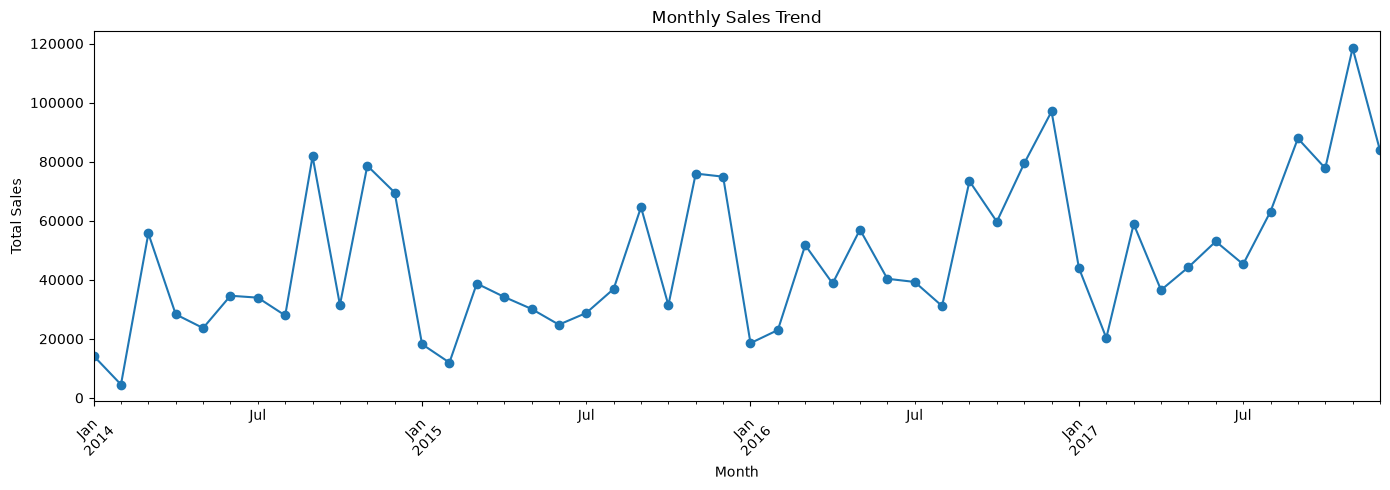

In [5]:
# Create a Year-Month column for grouping
df["Order YearMonth"] = df["Order Date"].dt.to_period("M")

monthly_sales = df.groupby("Order YearMonth")["Sales"].sum()

plt.figure(figsize=(14, 5))
monthly_sales.plot(kind="line", marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("Images/monthly_sales_trend.png", dpi=150)
plt.show()

**Observation:** Sales show a strong seasonal and upward pattern across the 4-year period (2014-2017). Every year has a sharp dip in January/February followed by growth through the year, with a pronounced spike each **November-December** (peaking around ₹120,000 in Nov 2017) — consistent with holiday-season shopping. There's also a clear year-over-year growth trend: each year's peak is higher than the last (2014 peak ~₹82K, 2015 ~₹79K, 2016 ~₹97K, 2017 ~₹119K), suggesting the business is growing overall alongside the seasonal cycle.

### Customer Segment Analysis

Note: This dataset does not include individual customer age or gender. As a substitute for demographic analysis, we examine the **Segment** field (Consumer, Corporate, Home Office), which represents the customer's business type.

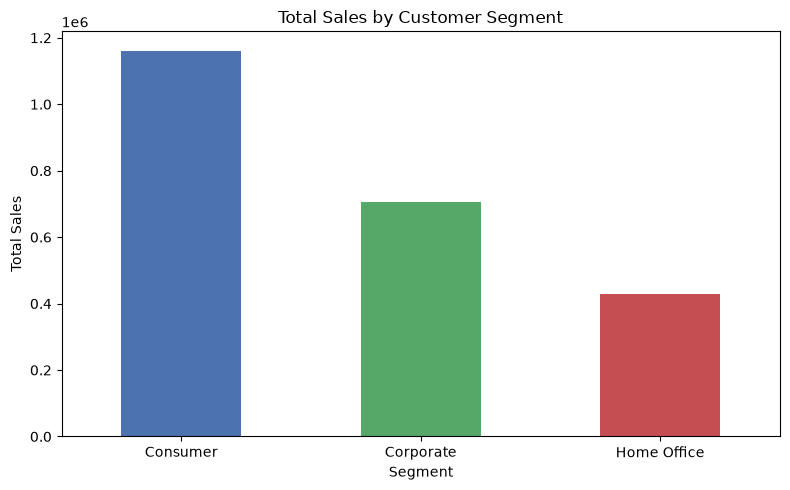

Segment
Consumer       1.161401e+06
Corporate      7.061464e+05
Home Office    4.296531e+05
Name: Sales, dtype: float64

In [6]:
segment_sales = df.groupby("Segment")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
segment_sales.plot(kind="bar", color=["#4C72B0", "#55A868", "#C44E52"])
plt.title("Total Sales by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("Images/sales_by_segment.png", dpi=150)
plt.show()

segment_sales

**Observation:** The **Consumer** segment drives the largest share of total sales (~₹1.16M), more than **Corporate** (~₹0.71M) and over 2.5x **Home Office** (~₹0.43M). This suggests individual/household buyers are the core revenue base, while Corporate and Home Office represent smaller, secondary markets — worth keeping in mind when we look at profitability by segment, since high sales volume doesn't necessarily mean high profit.

### Product Analysis: Top 10 Best-Selling Products & Revenue by Category

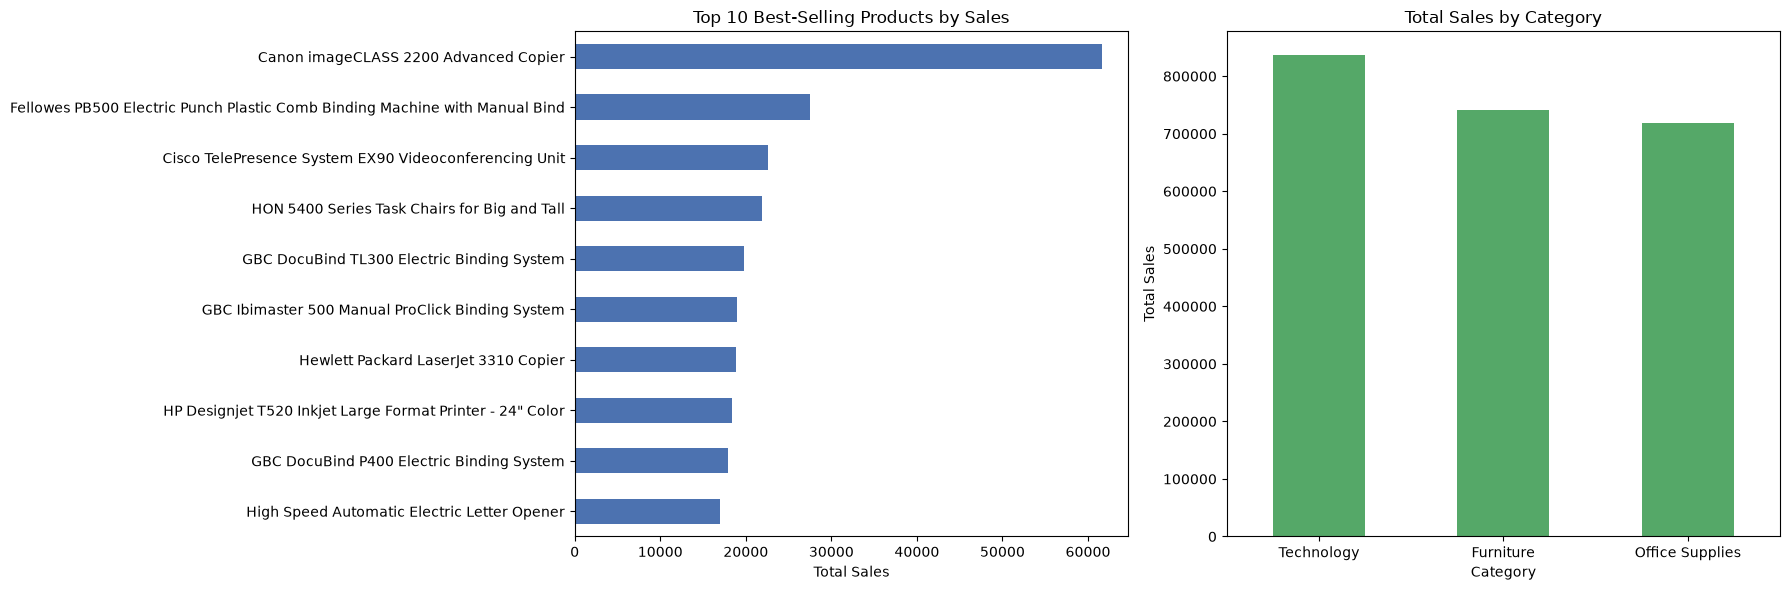

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


Category
Technology         836154.0330
Furniture          741999.7

In [7]:
top_products = df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

top_products.sort_values().plot(kind="barh", ax=axes[0], color="#4C72B0")
axes[0].set_title("Top 10 Best-Selling Products by Sales")
axes[0].set_xlabel("Total Sales")
axes[0].set_ylabel("")

category_sales.plot(kind="bar", ax=axes[1], color="#55A868")
axes[1].set_title("Total Sales by Category")
axes[1].set_xlabel("Category")
axes[1].set_ylabel("Total Sales")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig("Images/product_category_analysis.png", dpi=150)
plt.show()

print(top_products)
print("\n")
print(category_sales)

**Observation:** The **Canon imageCLASS 2200 Advanced Copier** is by far the top-selling product at ~₹61,600 — over double the second-highest item (Fellowes PB500 Binding Machine, ~₹27,450). Notably, 5 of the top 10 products are binding machines/systems, suggesting strong demand for office document-finishing equipment specifically.

At the category level, sales are fairly balanced: **Technology** leads (~₹836K), followed closely by **Furniture** (~₹742K) and **Office Supplies** (~₹719K) — no single category dominates the way Canon's copier dominates individual products.s

### Correlation Heatmap

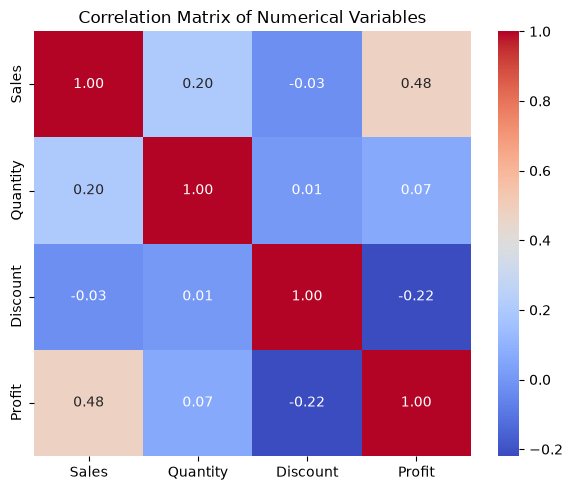

In [8]:
plt.figure(figsize=(6, 5))
corr = df[["Sales", "Quantity", "Discount", "Profit"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.savefig("Images/correlation_heatmap.png", dpi=150)
plt.show()

### Additional Insight: Does Discount Level Turn Orders Unprofitable?

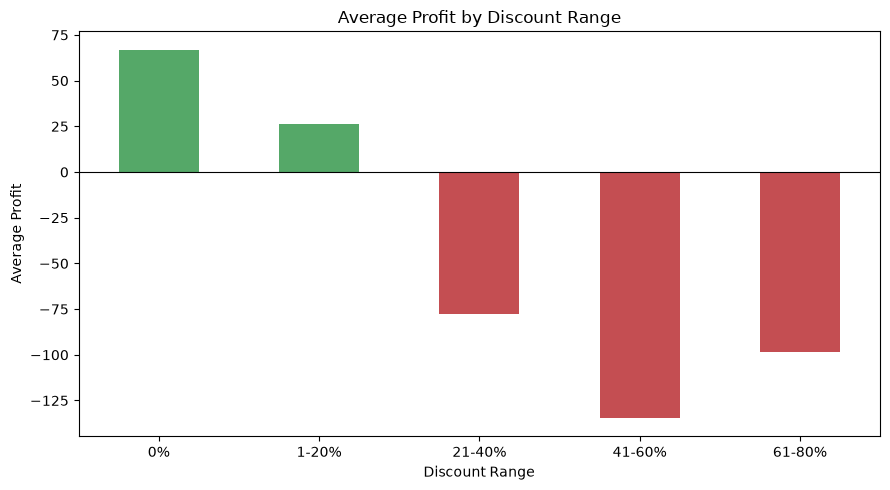

Discount Range
0%         66.900292
1-20%      26.501571
21-40%    -77.864055
41-60%   -134.624160
61-80%    -98.348741
Name: Profit, dtype: float64

In [9]:
df["Discount Range"] = pd.cut(df["Discount"], bins=[-0.01, 0, 0.2, 0.4, 0.6, 0.8],
                                labels=["0%", "1-20%", "21-40%", "41-60%", "61-80%"])

discount_profit = df.groupby("Discount Range", observed=True)["Profit"].mean()

plt.figure(figsize=(9, 5))
colors = ["#55A868" if x >= 0 else "#C44E52" for x in discount_profit]
discount_profit.plot(kind="bar", color=colors)
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Average Profit by Discount Range")
plt.xlabel("Discount Range")
plt.ylabel("Average Profit")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("Images/discount_vs_profit.png", dpi=150)
plt.show()

discount_profit

**Observation:** This chart makes the earlier correlation concrete and actionable. Orders with **no discount** average a healthy profit of ~₹67, and light discounts (1-20%) still stay profitable at ~₹26. But the moment discounts cross **21%**, average profit turns **negative** — bottoming out around **-₹135 at the 41-60% range**. 

This is a strong, non-obvious insight: discounting isn't just "less profit," it's actively pushing a large share of orders into loss-making territory once it exceeds ~20%. A clear business recommendation is to cap standard discounts at 20% except in specific strategic cases, and to review why the 41-60% discount tier is being applied so heavily if it's consistently unprofitable.

## Conclusion & Business Recommendations

Based on this analysis of the Superstore retail dataset, three actionable recommendations emerge:

1. **Cap discounts at 20% for standard orders.** Discounts above 20% are strongly associated with unprofitable orders, with the 41-60% range averaging a loss of ~₹135 per order. Discount policy should be reviewed and tightened, especially for the 21-80% range.

2. **Double down on the Consumer segment while investigating Corporate/Home Office growth.** Consumer drives ~₹1.16M in sales, more than double Home Office. Marketing and loyalty programs aimed at Consumer buyers are likely to have the highest ROI, while a separate strategy may be needed to grow the smaller B2B segments.

3. **Prepare inventory and staffing for the November-December seasonal peak.** Sales spike sharply every year in Nov-Dec (reaching ~₹119K in Nov 2017), with a slow start each January. Stocking up on top sellers like the Canon imageCLASS copier and binding machines ahead of Q4, and planning post-holiday inventory drawdown, should improve both sales capture and cash flow.